In [167]:
import pandas as pd
import numpy as np

In [168]:
df = pd.read_parquet('../data/processed/test_data.parquet')

In [187]:
df['eom'].max()

Timestamp('2025-12-31 00:00:00')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290295 entries, 0 to 290294
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   eom                         290295 non-null  datetime64[ns]
 1   gvkey                       290295 non-null  string        
 2   ret_exc_true                290295 non-null  float32       
 3   ret_exc_pred_ridge          290295 non-null  float32       
 4   ret_exc_pred_lasso          290295 non-null  float32       
 5   ret_exc_pred_elasticnet     290295 non-null  float32       
 6   ret_exc_pred_random_forest  290295 non-null  float32       
 7   ret_exc_pred_xgboost        290295 non-null  float32       
 8   ret_exc_pred_mlp            290295 non-null  float32       
dtypes: datetime64[ns](1), float32(7), string(1)
memory usage: 12.2 MB


In [170]:
df.head(10)

,eom,gvkey,ret_exc_true,ret_exc_pred_ridge,ret_exc_pred_lasso,ret_exc_pred_elasticnet,ret_exc_pred_random_forest,ret_exc_pred_xgboost,ret_exc_pred_mlp
0,2019-02-28,015526,0.001171,0.020226,0.006663,0.006269,0.003701,0.000689,0.005918
1,2019-03-31,015526,0.045420,0.013842,0.004197,0.003238,0.002365,0.000689,0.004226
2,2019-04-30,015526,0.033707,0.011336,0.004723,0.004725,0.004598,0.006034,0.005925
3,2019-05-31,015526,0.041998,0.013884,0.005018,0.004961,0.004192,0.006034,0.006281
4,2019-06-30,015526,-0.024651,0.013248,0.006456,0.007225,0.005248,0.015614,0.006553
5,2019-07-31,015526,0.014496,0.020432,0.008021,0.009310,0.003424,-0.000267,0.008121
6,2019-08-31,015526,0.019287,0.021624,0.009285,0.009332,0.003331,-0.003211,0.006743
7,2019-09-30,015526,0.010625,0.020896,0.009365,0.009814,0.006751,-0.000267,0.007245
8,2019-10-31,015526,0.017595,0.028114,0.009562,0.010758,-0.000157,-0.066159,0.008341
9,2019-11-30,015526,-0.003869,0.021191,0.007949,0.009352,0.001203,-0.057167,0.006808


In [171]:
models = ['ridge', 'lasso', 'elasticnet', 'random_forest', 'xgboost', 'mlp']

def get_returns(long_cutoff, short_cutoff):
    returns = pd.DataFrame()

    for model in models:
        pred_col = f'ret_exc_pred_{model}'
        top_pctile = df[df[pred_col] >= df.groupby('eom')[pred_col].transform(
            lambda x: x.quantile(long_cutoff)
        )]
        top_pctile = top_pctile.sort_values('eom')
        
        long_ret = top_pctile.groupby('eom')['ret_exc_true'].mean()
        
        if short_cutoff is not None:
            bottom_pctile = df[df[pred_col] <= df.groupby('eom')[pred_col].transform(
                lambda x: x.quantile(short_cutoff)
            )]
            bottom_pctile = bottom_pctile.sort_values('eom')
            
            short_ret = bottom_pctile.groupby('eom')['ret_exc_true'].mean()
            returns[model] = (long_ret - short_ret) / 2
        else:
            returns[model] = long_ret

    return returns

In [172]:
long_only_10 = get_returns(0.9, None)
long_short_10 = get_returns(0.9, 0.1)

In [173]:
def sharpe(returns_df, periods_per_year=12):  
    return (returns_df.mean() / returns_df.std()) * np.sqrt(periods_per_year)

In [174]:
sharpe(long_only_10)


ridge            1.086341
lasso            0.897743
elasticnet       0.991535
random_forest    0.851852
xgboost          0.525801
mlp              1.030076
dtype: float32

In [175]:
sharpe(long_short_10)

ridge            4.192125
lasso            3.123545
elasticnet       3.747833
random_forest    3.750479
xgboost          2.298905
mlp              4.092784
dtype: float32

<Axes: xlabel='eom'>

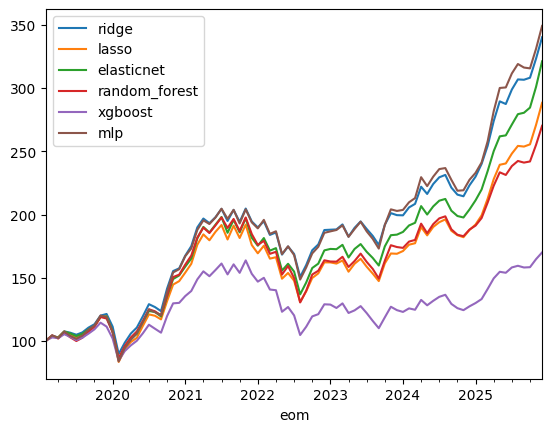

In [176]:
((long_only_10 + 1).cumprod() * 100).plot()

<Axes: xlabel='eom'>

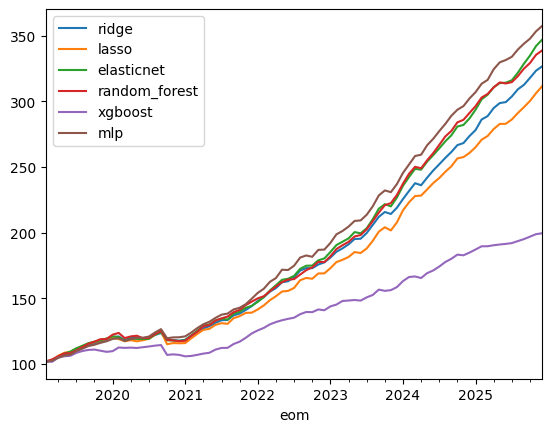

In [177]:
((long_short_10 + 1).cumprod() * 100).plot()

In [178]:
msci = pd.read_excel('../data/processed/msci.xlsx')
msci = msci.dropna()
msci.info()

<class 'pandas.core.frame.DataFrame'>
Index: 220 entries, 1 to 220
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     220 non-null    datetime64[ns]
 1   price    220 non-null    object        
 2   ret      220 non-null    float64       
 3   rf       220 non-null    float64       
 4   ret_exc  220 non-null    float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 10.3+ KB


In [179]:
msci.head()

,Date,price,ret,rf,ret_exc
1,2007-12-31,"1,385.123",-0.105586,0.21,-0.107686
2,2008-01-31,"1,410.495",0.018318,0.13,0.017018
3,2008-02-29,"1,411.283",0.000559,0.17,-0.001141
4,2008-03-31,"1,462.080",0.035993,0.18,0.034193
5,2008-04-30,"1,457.819",-0.002914,0.18,-0.004714


In [180]:
sharpe(msci['ret_exc'])

np.float64(0.112508383967351)

<Axes: >

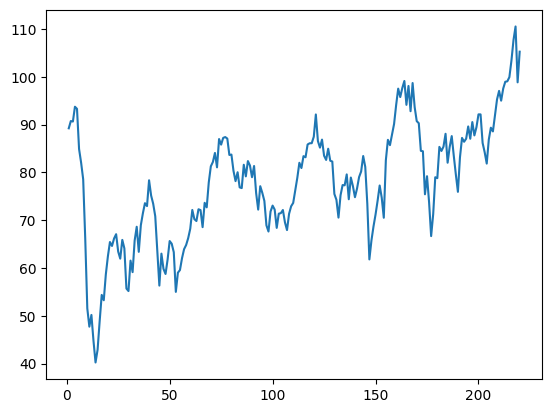

In [181]:
((msci['ret_exc'] + 1).cumprod() * 100).plot()


In [182]:
from sklearn.metrics import r2_score

for model in models:
    print(r2_score(df['ret_exc_true'], df[f'ret_exc_pred_{model}']))

0.0011575818061828613
0.003008425235748291
0.003911495208740234
0.002454996109008789
-0.007027626037597656
0.004581093788146973


In [183]:
for model in models:
    pred_col = f'ret_exc_pred_{model}'
    
    # demean within each month
    true_dm = df['ret_exc_true'] - df.groupby('eom')['ret_exc_true'].transform('mean')
    pred_dm = df[pred_col] - df.groupby('eom')[pred_col].transform('mean')
    
    print(f"{model}: {r2_score(true_dm, pred_dm):.4f}")

ridge: 0.0026
lasso: 0.0050
elasticnet: 0.0062
random_forest: 0.0059
xgboost: 0.0002
mlp: 0.0063


In [184]:
for model in models:
    pred_col = f'ret_exc_pred_{model}'
    ss_res = ((df['ret_exc_true'] - df[pred_col]) ** 2).sum()
    ss_tot = (df['ret_exc_true'] ** 2).sum()
    r2_oos = 1 - ss_res / ss_tot
    print(f"{model}: {r2_oos:.4f}")

ridge: 0.0023
lasso: 0.0042
elasticnet: 0.0051
random_forest: 0.0036
xgboost: -0.0058
mlp: 0.0058


In [185]:
for model in models:
    pred_col = f'ret_exc_pred_{model}'
    r2_list = []
    for date, grp in df.groupby("eom"):
        if len(grp) < 2:
            continue
        r2_list.append(r2_score(grp["ret_exc_true"], grp[pred_col]))
    print(f"{model}: {np.nanmean(r2_list):.4f}")

ridge: -0.2396
lasso: -0.2378
elasticnet: -0.2359
random_forest: -0.2399
xgboost: -0.2601
mlp: -0.2350


In [186]:
for model in models:
    pred_col = f'ret_exc_pred_{model}'
    
    short_rets = []
    long_rets = []
    for date, grp in df.groupby('eom'):
        n = max(1, int(0.1 * len(grp)))
        bot_idx = grp[pred_col].nsmallest(n).index
        top_idx = grp[pred_col].nlargest(n).index
        short_rets.append(grp.loc[bot_idx, 'ret_exc_true'].mean())
        long_rets.append(grp.loc[top_idx, 'ret_exc_true'].mean())
    
    print(f"{model}:")
    print(f"  Long  mean={np.mean(long_rets):.4f}, std={np.std(long_rets):.4f}")
    print(f"  Short mean={np.mean(short_rets):.4f}, std={np.std(short_rets):.4f}")

ridge:
  Long  mean=0.0162, std=0.0514
  Short mean=-0.0127, std=0.0647
lasso:
  Long  mean=0.0144, std=0.0553
  Short mean=-0.0134, std=0.0687
elasticnet:
  Long  mean=0.0157, std=0.0545
  Short mean=-0.0147, std=0.0677
random_forest:
  Long  mean=0.0136, std=0.0549
  Short mean=-0.0162, std=0.0693
xgboost:
  Long  mean=0.0076, std=0.0506
  Short mean=-0.0093, std=0.0660
mlp:
  Long  mean=0.0168, std=0.0561
  Short mean=-0.0143, std=0.0718
